In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('src')

from noise_utils import add_all_noise, add_gaussian_noise, add_shot_noise, add_baseline_drift

clean_signals = np.load('data/simulated_clean/signals.npy')
freq_axis = np.load('data/simulated_clean/freq_axis.npy')

print(f"Clean signals loaded : {clean_signals.shape}")


Clean signals loaded : (1000, 512)


In [3]:
import yaml

with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

noisy_signals = np.array([
    add_all_noise(sig, freq_axis, config) for sig in clean_signals
])

import os
os.makedirs('data/simulated_noisy', exist_ok=True)
np.save('data/simulated_noisy/signals_noisy.npy', noisy_signals)

print(f"Noisy signals shape : {noisy_signals.shape}")
print(f"Saved to            : data/simulated_noisy/")

Noisy signals shape : (1000, 512)
Saved to            : data/simulated_noisy/


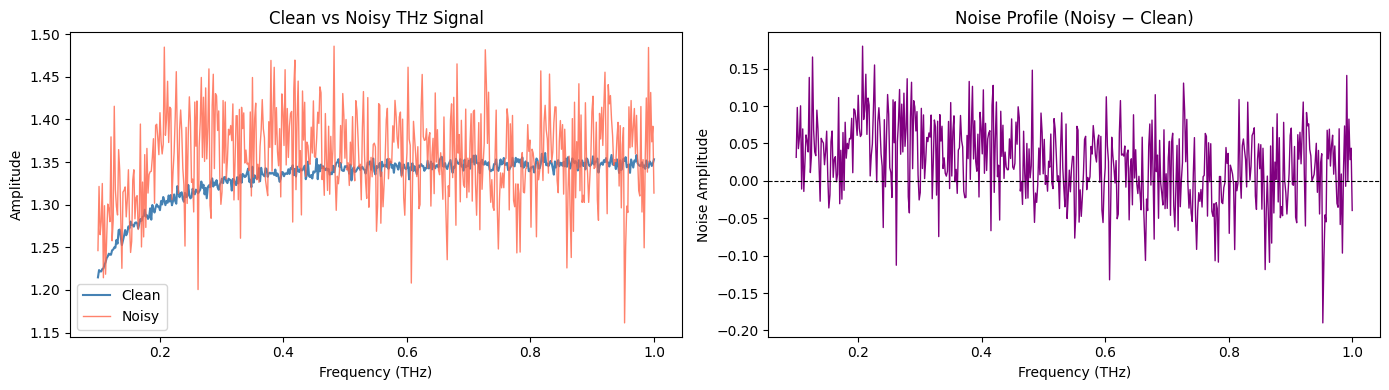

In [4]:
idx = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freq_axis, clean_signals[idx], color='steelblue', linewidth=1.5, label='Clean')
axes[0].plot(freq_axis, noisy_signals[idx], color='tomato', linewidth=1, alpha=0.8, label='Noisy')
axes[0].set_title('Clean vs Noisy THz Signal')
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(freq_axis, noisy_signals[idx] - clean_signals[idx], color='purple', linewidth=1)
axes[1].set_title('Noise Profile (Noisy − Clean)')
axes[1].set_xlabel('Frequency (THz)')
axes[1].set_ylabel('Noise Amplitude')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/02_clean_vs_noisy.png', dpi=150)
plt.show()